# Deep Learning

## Artificial Neural Networks
Objective:
  1. MNIST el yazısı rakamları veri seti kullanarak yapay sinir ağı ANN modeli ile sınıflandırma
  2. Model, rakamları (0-9) doğru şekilde tanımlamayı öğrenir.

Veri seti:
  1. mnist: 28x28 piksel boyutlarında el yazısı ile yazılmış 0-9 arasında toplam 70000 görüntü var
  2. 60000 training, 10000 test veri seti

Plan/program:
  1. veri seti yükleme ve örnek görüntülerin görselleştirilmesi
  2. normalizasyon (0-1 arasına sıkıştırma)
  3. etiketlerin kategorik hale getirilmesi
  4. yapay sinir ağı mimarisinin oluşturulması
  5. modelin derlenmesi
  6. erken durdurma (early stopping) en iyi modelin kaydedilmesi (model check point) callback lerinin kullanılması
  7. eğitim ve doğrulama metriklerinin görselleştirilmesi




In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense # tam bağlı katman

import matplotlib.pyplot as plt


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


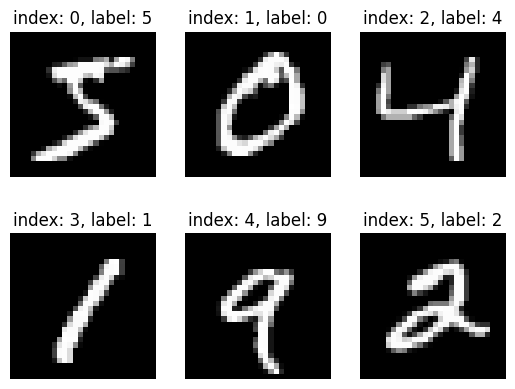

In [ ]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ilk birkaç örneği görselleştir
plt.figure()
for i in range(6):

  plt.subplot(2,3, i+1)
  plt.imshow(x_train[i], cmap = "gray")
  plt.title(f"index: {i}, label: {y_train[i]}")
  plt.axis("off")
plt.show()

In [ ]:
# Normalize the dataset
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1]*x_train.shape[2])).astype("float32")/255# 60000, 28,28 -> 60000, 784
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1]*x_test.shape[2])).astype("float32")/255

In [ ]:
# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# ANN model
model = Sequential()

In [ ]:
model.add(Dense(512, activation = "relu", input_shape = (28*28,)))
model.add(Dense(256, activation="tanh"))
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
# callback tanımlama
early_stopping = EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights=True)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs = 2,
    batch_size = 64,
    validation_split = 0.2,
    callbacks = [early_stopping]
)

Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9360 - loss: 0.2124 - val_accuracy: 0.9555 - val_loss: 0.1444
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9729 - loss: 0.0865 - val_accuracy: 0.9746 - val_loss: 0.0891


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9750 - loss: 0.0787
0.9750000238418579


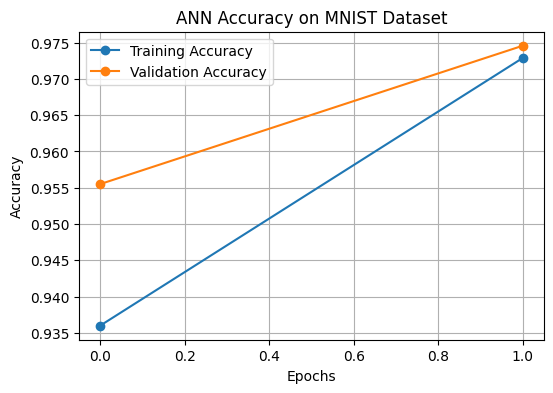

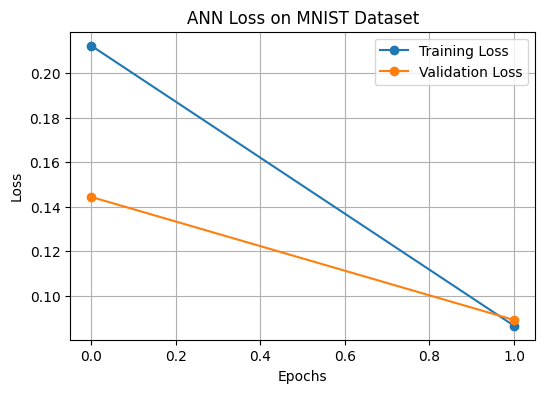

In [ ]:
# accuracy training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["accuracy"], marker = "o", label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], marker = "o", label = "Validation Accuracy")
plt.title("ANN Accuracy on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# loss training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["loss"], marker = "o", label = "Training Loss")
plt.plot(history.history["val_loss"], marker = "o", label = "Validation Loss")
plt.title("ANN Loss on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## CNN
Objective:
  1. CNN kullanma
  2. cifar-10 veri seti ile çok sınıflı görüntü sınıflandırma problemi çözme

Veri seti:
  1. cifar-10, 32x32 boyutlarında renkli görüntülerden oluşan 10 sınıflı bir görüntü veri seti.
  2. 60000 eğitim veri seti, 50000 train veri seti, 10000 test veri seti
  3. airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

Plan/program:
  1. kütüphanelerin içeriye aktarılması
  2. cifar-10 veri setinin yüklenmesi
  3. veri görselleştirme
  4. veri ön işleme: normalization, one hot encoding
  5. veri arttırma
  6. cnn mimarisinin oluşturulması
  7. modelin derlenmesi
  8. modelin eğitilmesi
  9. modelin test edilmesi

In [ ]:
# 1. kütüphanelerin içeriye aktarılması
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # veri seti
from tensorflow.keras.utils import to_categorical # encoding
from tensorflow.keras.models import Sequential # sirali model
from tensorflow.keras.layers import Conv2D, MaxPooling2D # feature extraction
from tensorflow.keras.layers import Flatten, Dense, Dropout # classification
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

from sklearn.metrics import classification_report

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


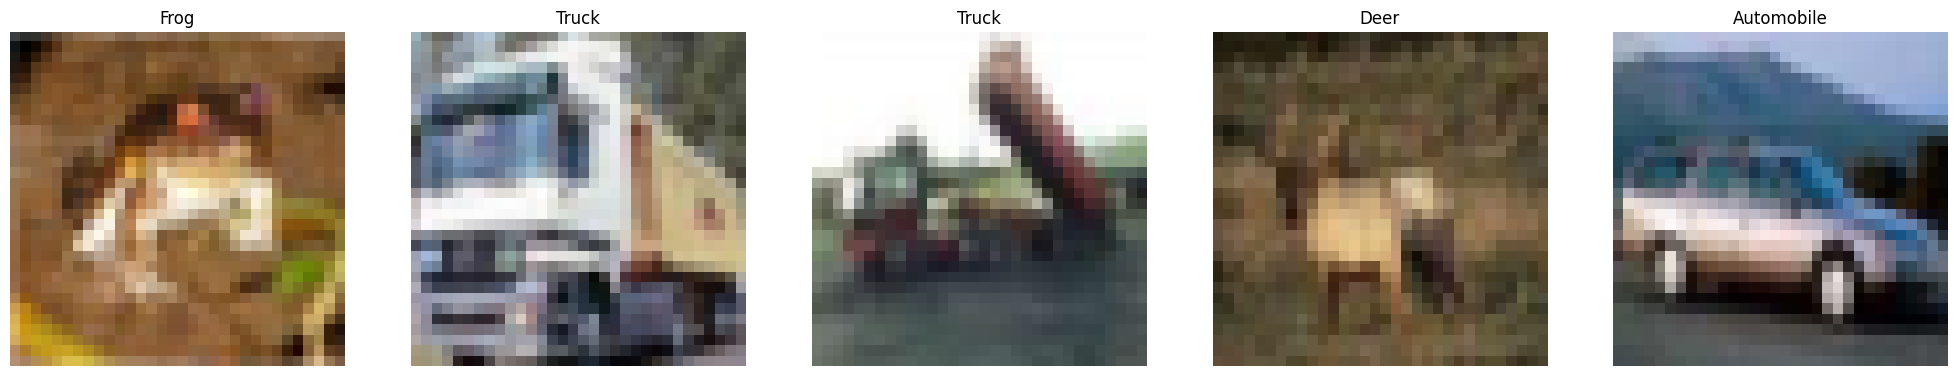

In [ ]:
# 2. veri setinin yüklenmesi
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 3. görselleştirme
class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse","Ship","Truck"]

# bazi goruntuleri görselleştir
fig, axes = plt.subplots(1, 5, figsize = (25,20))

for i in range(5):
  axes[i].imshow(x_train[i])
  label = class_labels[y_train[i][0]]
  axes[i].set_title(label)
  axes[i].axis("off")
plt.show()

In [ ]:
# 4. veri ön işleme: normalizasyon, one hot encoding
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

# one hot encoding
y_train = to_categorical(y_train, 10) # 10 class var
y_test = to_categorical(y_test, 10)

In [ ]:
# 5. veri arttırma (data augmentation)
datagen = ImageDataGenerator(
    rotation_range = 20, # 20 dereceye kadar dondurme sağlar
    width_shift_range = 0.2, # goruntuyu yatayda %20 kaydırır
    height_shift_range = 0.2, # goruntuyu dikeyde %20 kaydırır
    shear_range = 0.2, # goruntu üzerinde kaydırma
    zoom_range = 0.2, # goruntuye zoom uygulama
    horizontal_flip = True, # yatayda ters çevirme
    fill_mode = "nearest" # boş alanları doldurmak için en yakin pizel değerleri
)

datagen.fit(x_train)

In [ ]:
# 6. cnn mimarisi oluşturma
model = Sequential()

# feature extraction
model.add(Conv2D(32, (3,3), padding = "same", activation="relu", input_shape = x_train.shape[1:]))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# feature extraction
model.add(Conv2D(64, (5,5), padding = "same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# classification
model.add(Flatten())
model.add(Dense(1024, activation = "relu"))
model.add(Dropout(0.4))
model.add(Dense(512, activation = "relu"))
model.add(Dropout(0.4))
model.add(Dense(10, activation="softmax"))

In [ ]:
# 7. model derlenmesi (compile)
model.compile(optimizer = RMSprop(), loss = "categorical_crossentropy", metrics = ["accuracy"])

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size = 512), # data augmentation
    epochs = 10,
    validation_data = (x_test, y_test)
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 376ms/step - accuracy: 0.1956 - loss: 2.1734 - val_accuracy: 0.3632 - val_loss: 1.9158
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.2950 - loss: 1.9393 - val_accuracy: 0.3053 - val_loss: 1.8941
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 326ms/step - accuracy: 0.3443 - loss: 1.8116 - val_accuracy: 0.4639 - val_loss: 1.5371
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 325ms/step - accuracy: 0.3806 - loss: 1.7201 - val_accuracy: 0.4365 - val_loss: 1.5354
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.4110 - loss: 1.6391 - val_accuracy: 0.5158 - val_loss: 1.3934
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 30s 310ms/step - accuracy: 0.4336 - loss: 1.5767 - val_accuracy: 0.5017 - val_loss: 1.4129
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 317ms/step - accuracy: 0.4544 - loss: 1.5258 - val_accuracy: 0.5428 - val_loss: 1.2814
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - accuracy: 0.4688 - loss: 1.4821 - val_accu

In [ ]:
# 9. modelin test edilmesi
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis = 1)
y_true = np.argmax(y_test, axis = 1)

print(classification_report(y_true, y_pred_class, target_names=class_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

    Airplane       0.58      0.72      0.65      1000
  Automobile       0.60      0.79      0.68      1000
        Bird       0.55      0.48      0.51      1000
         Cat       0.47      0.36      0.40      1000
        Deer       0.60      0.46      0.52      1000
         Dog       0.49      0.54      0.51      1000
        Frog       0.81      0.52      0.64      1000
       Horse       0.65      0.66      0.66      1000
        Ship       0.62      0.80      0.70      1000
       Truck       0.62      0.62      0.62      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.59     10000
weighted avg       0.60      0.59      0.59     10000



## RNN
Objective:
  1. RNN ile duygu analizi (sentiment analysis) gerçekleştirmek
  2. Sınıflandırma problemi: restoran yorumları, etiket: positive yada negative

Steps:
  1. gerekli kütüphanelerin içeri aktarılması
  2. restoran yorumları veri seti oluşturulması
  3. text preprocessing (text preprocessing): tokenizasyon, padding, label encoding, train test split
  4. embedding: word2vec ile sayısallaştırma (sayısal vektör oluşturma)
  5. RNN modeli oluşturma
  6. RNN modelinin derlenmesi ve eğitimi
  7. RNN modelinin test veri seti üzerinden değerlendirilmesi

In [4]:
# pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.8 MB/s eta 0:00:00


In [5]:
# 1. gerekli kütüphanelerin içeriye aktarılması
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential # base model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer # kelimeleri sayısal indekslere çeviriyor

from tensorflow.keras.utils import pad_sequences
from gensim.models import Word2Vec # embedding

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [6]:
# 2. veri setinin oluşturulması
reviews_data = {
    "text": [
        "This restaurant is absolutely fantastic! The food was delicious and the service was impeccable.",
        "The ambiance was delightful, and the staff were incredibly attentive. A perfect evening!",
        "Every dish was a culinary masterpiece. Truly enjoyed the innovative menu.",
        "Highly recommend this place! The flavors were exquisite and the presentation was beautiful.",
        "Such a wonderful dining experience from start to finish. Five stars!",
        "The service was prompt and friendly, and the food exceeded all expectations.",
        "Loved the cozy atmosphere and the incredibly fresh ingredients. Will definitely return.",
        "Best meal I've had in a long time. The dessert was particularly memorable.",
        "A hidden gem with amazing dishes and a great wine selection. Absolutely superb.",
        "The staff went above and beyond to make our anniversary special. Thank you!",
        "Fantastic spot for families. Kids loved the options, and parents loved the peace.",
        "The vibrant flavors of their vegetarian options are truly a delight.",
        "Incredible value for money considering the quality of the food and service.",
        "The chef clearly puts a lot of passion into each plate. Highly impressed.",
        "A truly authentic experience. Felt like I was dining in my grandmother's kitchen.",
        "The live music added a perfect touch to an already fantastic meal.",
        "Outstanding coffee and pastries! A great place to start the day.",
        "The seafood was incredibly fresh and perfectly cooked. A must-try!",
        "The interior design is stunning, creating a very relaxing dining environment.",
        "Portion sizes were generous, and everything tasted home-cooked and delicious.",
        "The cocktails were creative and perfectly balanced. A fantastic bar.",
        "Even simple dishes were elevated to an art form. Pure genius.",
        "The breakfast spread was extensive and every item was delicious.",
        "Polite and efficient service. They made sure we had everything we needed.",
        "A great place for a romantic dinner. The lighting and setting were perfect.",
        "The outdoor seating area is lovely, especially on a warm evening.",
        "They cater very well to dietary restrictions without compromising on taste.",
        "The manager personally ensured our satisfaction. Exemplary customer service.",
        "Such a memorable meal, from appetizers to dessert. Can't wait for next time.",
        "The fusion cuisine was expertly executed, offering unique and delicious tastes.",
        "Their homemade pasta is to die for! So fresh and flavorful.",
        "Always a pleasure to dine here. Consistently excellent food and service.",
        "The prices are reasonable for the high quality of food you receive.",
        "A charming little bistro with a big heart and even bigger flavors.",
        "The atmosphere is buzzing and lively, but not overwhelmingly loud.",
        "The presentation of each dish was like a work of art. Almost too pretty to eat!",
        "A perfect brunch spot with delicious mimosas and creative menu items.",
        "The wine list is extensive and thoughtfully curated to pair with the food.",
        "Made a reservation, and our table was ready exactly on time. Seamless experience.",
        "The soup of the day was surprisingly complex and utterly satisfying.",
        "Freshly baked bread served with our meal was a delightful touch.",
        "The restaurant was spotlessly clean, which is always a good sign.",
        "They offer excellent vegetarian and vegan options, which is a huge plus.",
        "The dessert menu is innovative and every item we tried was fantastic.",
        "The staff were very knowledgeable about the menu and offered great recommendations.",
        "A truly positive experience that left us wanting to come back soon.",
        "The children's menu was well thought out and healthy, not just typical fried fare.",
        "From the moment we walked in, we felt welcomed and valued as guests.",
        "The portion sizes are just right, leaving you satisfied but not overly full.",
        "This place is a gem! Everything was perfect, from the food to the service.",

        "Terrible experience. The meal was cold and the staff was very rude. Would not recommend.",
        "The service was incredibly slow, and our order was completely wrong. Disappointing.",
        "Overpriced and underwhelming food. Definitely not worth the hype or the money.",
        "The atmosphere was drab, and the noise level made conversation impossible.",
        "Worst restaurant I've ever been to. Everything was awful from start to finish.",
        "The food was bland and lacked any flavor. Tasted like it came from a can.",
        "Waited an hour for a table despite having a reservation. Unacceptable.",
        "The waiter spilled a drink on me and barely apologized. Poor customer service.",
        "Felt sick after eating here. The hygiene standards seemed questionable.",
        "The portions were tiny for the exorbitant price. Left feeling hungry.",
        "The coffee tasted burnt, and the pastries were stale. A terrible breakfast.",
        "The restaurant was dirty, and the tables weren't properly cleaned.",
        "My steak was overcooked, and my companion's fish was undercooked. Inconsistent quality.",
        "The manager was unhelpful and dismissive when we raised our concerns.",
        "Absolutely no vegetarian options, which is ridiculous in this day and age.",
        "The music was too loud and inappropriate for a dining setting.",
        "The chairs were uncomfortable, and the overall decor felt very dated.",
        "They charged us for items we didn't order. Had to argue to get it removed.",
        "The restrooms were disgusting. A clear sign of neglect.",
        "I found a hair in my food. Completely lost my appetite.",
        "The drinks were watered down and very expensive. Don't bother.",
        "The online menu was misleading, and many items were unavailable.",
        "The parking was a nightmare, and the restaurant didn't offer any solutions.",
        "The staff seemed miserable and completely uninterested in serving us.",
        "This place needs a complete overhaul. Nothing redeeming about it.",
        "The dessert was sickly sweet and inedible. A huge disappointment.",
        "They completely ignored our requests for a quieter table.",
        "The ingredients tasted cheap and not fresh at all. Very disappointing.",
        "The seating was too cramped, and we felt like we were eating with strangers.",
        "The bill was outrageously high for the quality of food and experience.",
        "Definitely won't be returning. A complete waste of time and money.",
        "The children's menu consisted only of unhealthy fried foods.",
        "The soup was cold, and the bread was hard. Simple things done wrong.",
        "The reservation system is a mess. They clearly overbooked.",
        "The ventilation was poor, and the smell of grease was overpowering.",
        "The food arrived lukewarm after a very long wait.",
        "Their 'specialty' dish was incredibly greasy and tasteless.",
        "The high chairs for children were very dirty and sticky.",
        "My allergic reaction was almost certainly due to cross-contamination here.",
        "The staff seemed to be arguing among themselves, creating an awkward atmosphere.",
        "The coffee was bitter, and the milk was curdled. Undrinkable.",
        "Absolutely nothing to recommend about this establishment. Avoid.",
        "The tables were wobbly, and the cutlery felt cheap and dirty.",
        "The noise from the kitchen was very disruptive throughout our meal.",
        "The portions were inconsistent; some very large, some tiny.",
        "The restaurant felt understaffed, leading to poor service.",
        "The presentation of the food was sloppy and unappetizing.",
        "The prices were not clearly displayed, leading to a shock at the bill.",
        "Found plastic in my salad. Unacceptable and dangerous.",
        "A truly negative experience from start to finish. Would not recommend to anyone."
    ],
    "labels": [
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",

        "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative", "negative"
    ]
}

In [17]:
pd.set_option('display.max_colwidth', None) # Display full content of columns

In [18]:
# 3. text preprocessing
df = pd.DataFrame(reviews_data)
df.head()

,text,labels
0,This restaurant is absolutely fantastic! The food was delicious and the service was impeccable.,positive
1,"The ambiance was delightful, and the staff were incredibly attentive. A perfect evening!",positive
2,Every dish was a culinary masterpiece. Truly enjoyed the innovative menu.,positive
3,Highly recommend this place! The flavors were exquisite and the presentation was beautiful.,positive
4,Such a wonderful dining experience from start to finish. Five stars!,positive


In [19]:
# tokenizer
tokenizer = Tokenizer() # kelimeleri sayısal indekslere çevir
tokenizer.fit_on_texts(df["text"]) # kelime sözlüğü
text_sequences = tokenizer.texts_to_sequences(df["text"])
word_index = tokenizer.word_index
print(word_index)

{'the': 1, 'and': 2, 'was': 3, 'a': 4, 'to': 5, 'were': 6, 'food': 7, 'for': 8, 'of': 9, 'is': 10, 'very': 11, 'service': 12, 'we': 13, 'from': 14, 'our': 15, 'not': 16, 'menu': 17, 'experience': 18, 'in': 19, 'felt': 20, 'my': 21, 'this': 22, 'restaurant': 23, 'staff': 24, 'meal': 25, 'with': 26, 'they': 27, 'fantastic': 28, 'delicious': 29, 'incredibly': 30, 'perfect': 31, 'truly': 32, 'place': 33, 'absolutely': 34, 'recommend': 35, 'dining': 36, 'start': 37, 'atmosphere': 38, 'fresh': 39, 'time': 40, 'dessert': 41, 'great': 42, 'options': 43, 'quality': 44, 'like': 45, 'an': 46, 'everything': 47, 'tasted': 48, 'on': 49, 'completely': 50, 'every': 51, 'dish': 52, 'flavors': 53, 'presentation': 54, 'finish': 55, 'loved': 56, 'definitely': 57, 'had': 58, 'you': 59, 'their': 60, 'vegetarian': 61, 'are': 62, 'money': 63, 'clearly': 64, 'coffee': 65, 'day': 66, 'made': 67, 'here': 68, 'high': 69, 'too': 70, 'items': 71, 'reservation': 72, 'table': 73, 'which': 74, 'about': 75, 'us': 76, '

In [20]:
# padding
"""
Cümle uzunluklarını eşit seviyeye getirme
The ambiance was delightful, and the staff were incredibly attentive. A perfect evening! # 16
0 0 Every dish was a culinary masterpiece. Truly enjoyed the innovative menu. # 14 - 16

"""
max_sequence_len = max(len(seq) for seq in text_sequences)
print(max_sequence_len)

16


In [21]:
X = pad_sequences(text_sequences, maxlen = max_sequence_len)
print(X.shape) # 100, 16

(100, 16)


In [22]:
# label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["labels"]) #
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape)

(80, 16)


In [27]:
# 4. embedding
sentences = [text.split() for text in df["text"]]

# word2vec modeli
embedding_dim = 50
word2vec_model = Word2Vec(sentences, vector_size=embedding_dim, window = 5, min_count = 1)

# embedding matrisi
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, idx in word_index.items():
  if word in word2vec_model.wv:
    embedding_matrix[idx] = word2vec_model.wv[word]
print(f"embedding matris: \n{embedding_matrix}")
print(embedding_matrix.shape)

embedding matris: 
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.58773940e-02 -1.95253268e-02 -2.38207038e-04 ... -5.64605650e-03
  -1.81564633e-02  9.27848183e-03]
 [-8.43766611e-04 -3.98449374e-05  1.03420494e-02 ...  1.84122510e-02
   1.09645743e-02  1.88358501e-02]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-4.48169047e-03  3.83632467e-03  1.56950764e-02 ...  5.59399370e-03
  -1.46674551e-02  1.46110281e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
(488, 50)


In [28]:
# 5. RNN Modeli oluşturma
model = Sequential()

model.add(Embedding(
    input_dim = len(word_index) + 1,
    output_dim = embedding_dim,
    weights = [embedding_matrix],
    input_length = max_sequence_len,
    trainable = False
))

model.add(SimpleRNN(units = 40, return_sequences=False))

model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
# 6. compile
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [30]:
# 7. training
model.fit(
    X_train, y_train,
    epochs = 10,
    batch_size = 2,
    validation_data = (X_test, y_test)
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5000 - loss: 0.6950 - val_accuracy: 0.5500 - val_loss: 0.6971
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6250 - loss: 0.6797 - val_accuracy: 0.5500 - val_loss: 0.6894
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6875 - loss: 0.6611 - val_accuracy: 0.5500 - val_loss: 0.6915
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6750 - loss: 0.6347 - val_accuracy: 0.6500 - val_loss: 0.7304
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7125 - loss: 0.5875 - val_accuracy: 0.5000 - val_loss: 0.7085
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7375 - loss: 0.5338 - val_accuracy: 0.5000 - val_loss: 0.7130
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8375 - loss: 0.4754 - val_accuracy: 0.5000 - val_loss: 0.8212
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7875 - loss: 0.4185 - val_accuracy: 0.4000 - val_los

## LSTM

Objective:
  1. 20 farklı haber kategorisinden oluşan 20 Newsgroup veri setini kullanarak metin sınıflandırma

Veri seti:
  1. sklearn: 20 newsgroup veri seti
  2. 20 farklı haber kategorisi: teknoloji, spor, uzay, sağlık vb.
  3. toplam metin sayısı 18k

Steps:
  1. gerekli kütüphanelerin içeriye aktarılması
  2. veri setinin yüklenmesi
  3. tokenization kelimelerin sayısal indekslere çevrilmesi.
  4. padding (tüm metinlerin aynı uzunluğa getirilmesi)
  5. label encoding
  6. eğitim ve test ayrımı
  7. LSTM modelinin oluşturulması
  8. LSTM modeli eğitimi
  9. LSTM testtleri
  10. Accuracy ve Loss grafiklerinin çizdirilmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# 2. veri setinin yüklenmesi
newsgroup = fetch_20newsgroups(subset = "all")
X = newsgroup.data # metinler
y = newsgroup.target # metinlere karşılık gelen etiketler
# kaç epochluk training yaptınız ve accuracy ne çıktı?

In [3]:
# 3 - 4 tokenization ve padding
tokenizer = Tokenizer(num_words = 10000) # en çok kullanılan 10k kelimeyi al
tokenizer.fit_on_texts(X)
X_sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(X_sequences, maxlen = 100)

In [4]:
X_padded.shape

(18846, 100)

In [5]:
y

array([10,  3, 17, ...,  3,  1,  7])

In [6]:
# 5. label encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded

array([10,  3, 17, ...,  3,  1,  7])

In [7]:
# 6. train test split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y , test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(15076, 100)
(3770, 100)


In [8]:
# 7. LSTM modelinin oluşturulması
model = Sequential()

model.add(Embedding(
    input_dim = 10000, # sözlükteki kelime sayısı
    output_dim = 64, # kelime vektörlerinin boyutu
    input_length = 100
))

model.add(LSTM(
    units = 8, # cell sayısı
    return_sequences = False
))

model.add(Dropout(0.5))

model.add(Dense(20, activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
# model compile
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [11]:
early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 5, restore_best_weights=True)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.3,
    callbacks = [early_stopping]
                    )

Epoch 1/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1035 - loss: 2.8855 - val_accuracy: 0.1669 - val_loss: 2.6636
Epoch 2/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1741 - loss: 2.5503 - val_accuracy: 0.2417 - val_loss: 2.3887
Epoch 3/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2271 - loss: 2.3200 - val_accuracy: 0.3199 - val_loss: 2.2290
Epoch 4/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2793 - loss: 2.1445 - val_accuracy: 0.3759 - val_loss: 2.1154
Epoch 5/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3180 - loss: 2.0216 - val_accuracy: 0.3911 - val_loss: 2.0276
Epoch 6/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3455 - loss: 1.8979 - val_accuracy: 0.4095 - val_loss: 1.9957
Epoch 7/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3626 - loss: 1.8055 - val_accuracy: 0.4373 - val_loss: 1.8902
Epoch 8/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3846 - loss: 1.7332 - val_accu

In [13]:
# 8. test veri seti ile test
loss, accuracy = model.evaluate(X_test, y_test)

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5034 - loss: 1.7599


In [14]:
accuracy

0.5034482479095459

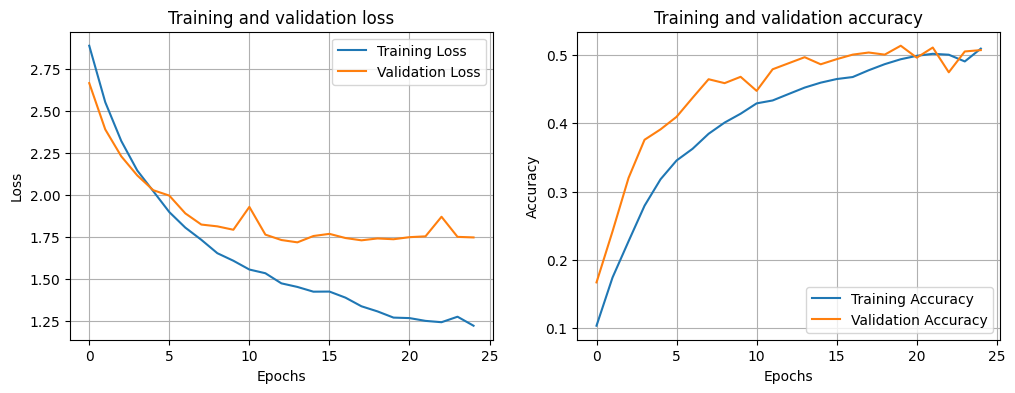

In [15]:
# 9. accuracy ve loss değerlerinin çizdirilmesi
plt.figure(figsize = (12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()